# HA-AdaRound — Results Visualization

Use this notebook (VS Code / Jupyter) to analyse the outputs generated by the MASE terminal pipeline.

**Pipeline stages covered here:**
- Stage 1 — Sensitivity Profiling (`run_profiling.py`)
- Stage 2 — Mixed-Precision Allocation
- Stage 2.5 — AdaRound Learned Rounding
- Stage 3 — MASE/CHOP Quantization

**Expected input files** (from `outputs/`):
- `sensitivity_scores.json` — raw param-level gradient norms (Stage 1)
- `layer_sensitivity.json` — module-level aggregated scores (Stage 1)
- `quant_config.json` — CHOP bit-width assignments (Stage 3)
- `eval_baseline.json` — fp32 model evaluation results *(optional)*
- `eval_quantized.json` — quantized model evaluation results *(optional)*

In [30]:
import json
import pathlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
OUTPUT_DIR = pathlib.Path("../outputs")

def load_json(name: str) -> dict | list:
    path = OUTPUT_DIR / name
    if not path.exists():
        print(f"[WARNING] {path} not found — skipping.")
        return {}
    with open(path) as fh:
        return json.load(fh)

print("Imports OK")

Imports OK


## 1. Per-Layer Sensitivity Scores

Visualise the normalised gradient-norm sensitivity for each module.  
Dashed lines show the thresholds used by the allocator to assign bit-widths.

/var/folders/1m/7xl9twrx6n95gvvnzf_m7_7c0000gn/T/ipykernel_83627/2619109401.py:39: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig_a.tight_layout()
/Users/bossbaby07/.pyenv/versions/3.14.2/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


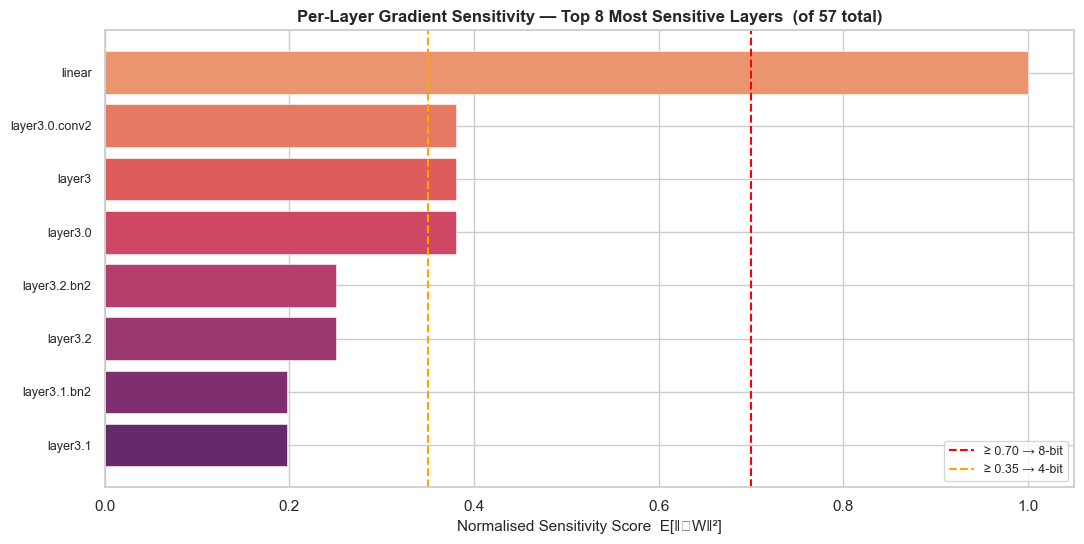

/var/folders/1m/7xl9twrx6n95gvvnzf_m7_7c0000gn/T/ipykernel_83627/2619109401.py:65: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig_b.tight_layout()


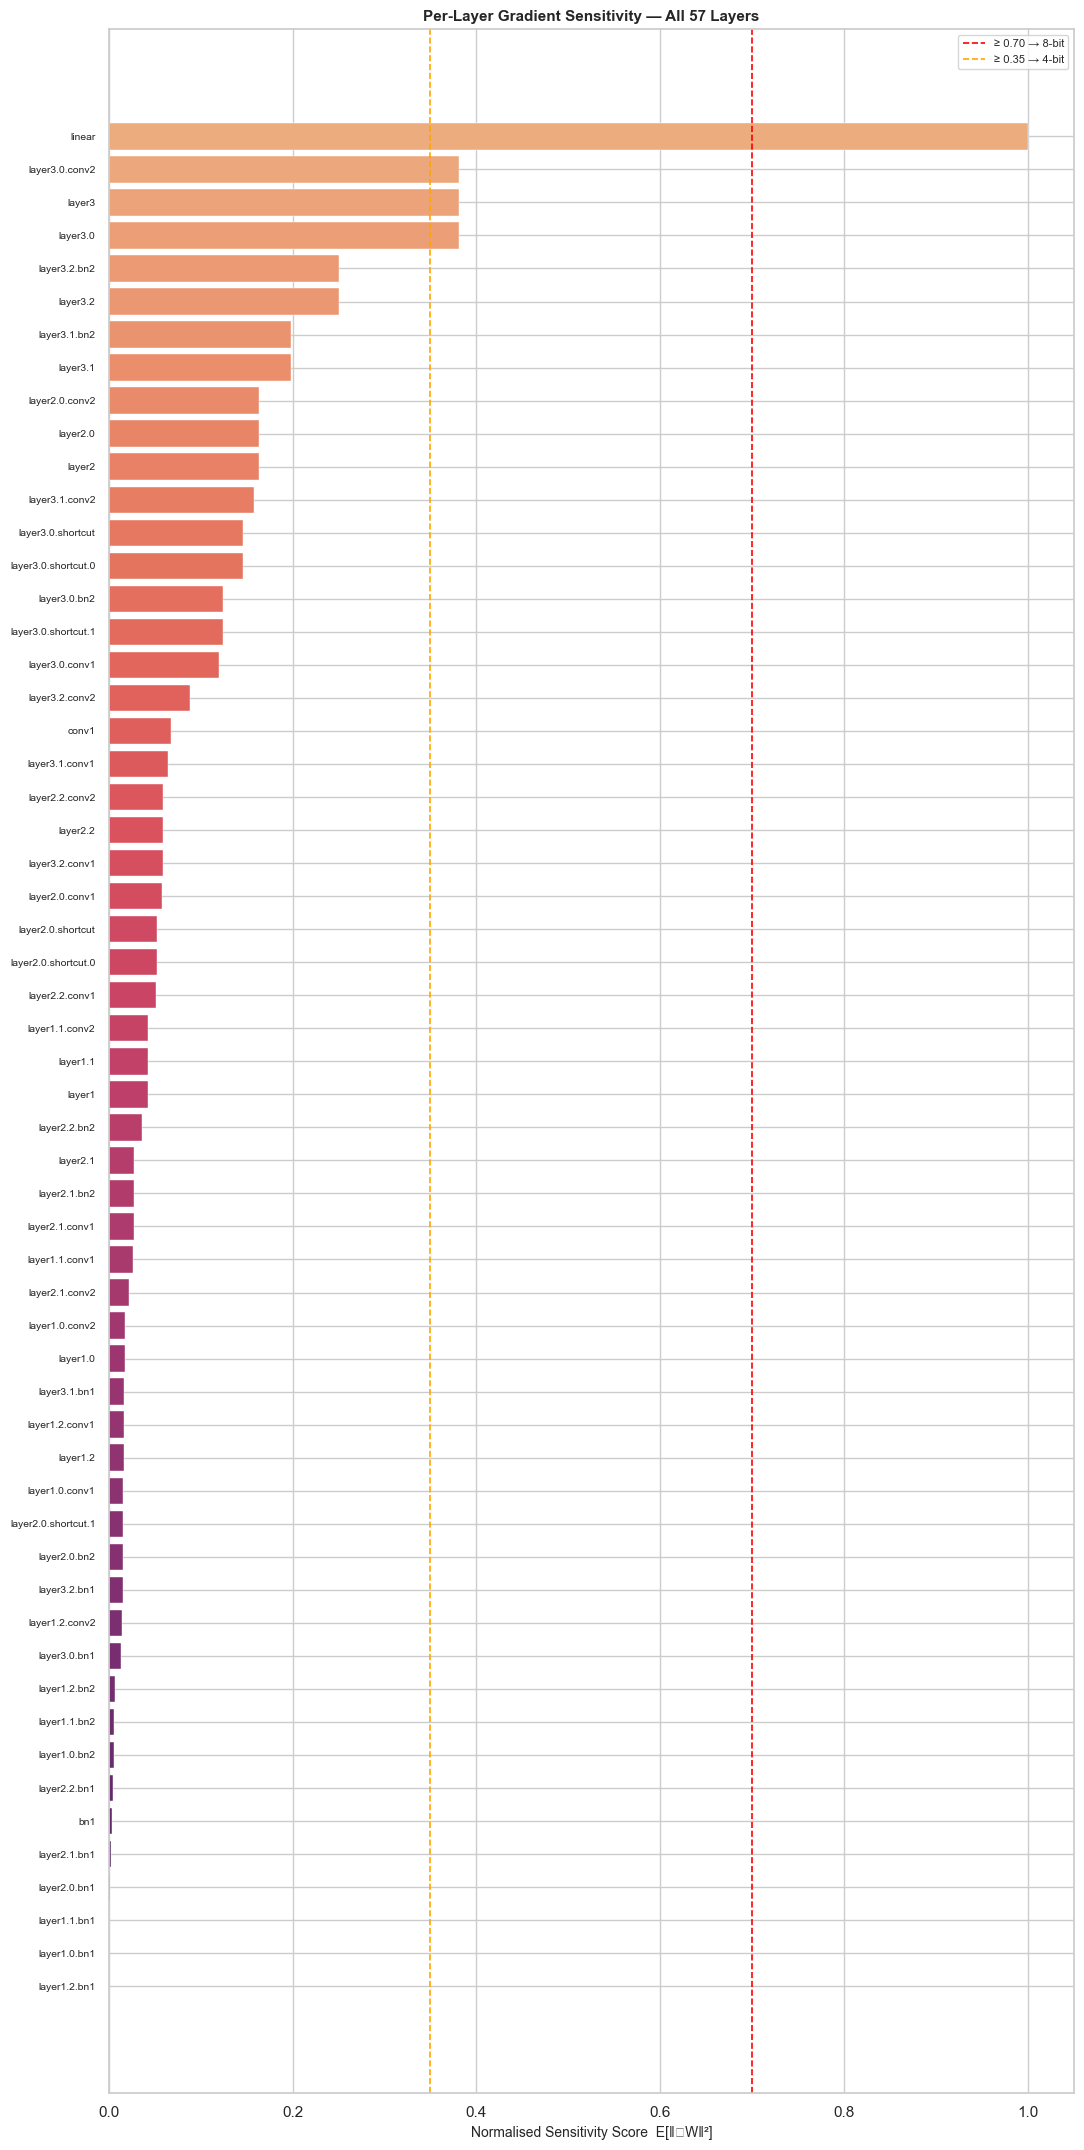

In [31]:
layer_scores = load_json("layer_sensitivity.json")

if layer_scores:
    df_sens = (
        pd.DataFrame(list(layer_scores.items()), columns=["layer", "sensitivity"])
        .query("sensitivity > 0")
        .sort_values("sensitivity", ascending=False)
        .reset_index(drop=True)
    )

    TOP_N   = 8       # layers shown in the summary panel
    BAR_H   = 0.38        # inches per bar in the full-detail panel
    palette = sns.color_palette("flare", len(df_sens))

    # ------------------------------------------------------------------ #
    # Panel A — Top-N most sensitive layers (always readable)
    # ------------------------------------------------------------------ #
    df_top = df_sens.head(TOP_N)

    fig_a, ax_a = plt.subplots(figsize=(11, 0.55 * TOP_N + 1.2))
    colors_top = sns.color_palette("flare", TOP_N)
    ax_a.barh(
        df_top["layer"][::-1],
        df_top["sensitivity"][::-1],
        color=colors_top[::-1],
        edgecolor="white", linewidth=0.4,
    )
    ax_a.axvline(0.70, color="red",    linestyle="--", lw=1.5, label="≥ 0.70 → 8-bit")
    ax_a.axvline(0.35, color="orange", linestyle="--", lw=1.5, label="≥ 0.35 → 4-bit")
    ax_a.set_xlabel("Normalised Sensitivity Score  E[‖∇W‖²]", fontsize=11)
    ax_a.set_title(
        f"Per-Layer Gradient Sensitivity — Top {TOP_N} Most Sensitive Layers  "
        f"(of {len(df_sens)} total)",
        fontsize=12, fontweight="bold",
    )
    ax_a.tick_params(axis="y", labelsize=9)
    ax_a.set_xlim(0, 1.05)
    ax_a.legend(fontsize=9)
    fig_a.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    # Panel B — Full layer list, height auto-scales with layer count
    # Only shown when there are more layers than TOP_N
    # ------------------------------------------------------------------ #
    if len(df_sens) > TOP_N:
        full_h = max(6, len(df_sens) * BAR_H)
        fig_b, ax_b = plt.subplots(figsize=(11, full_h))
        ax_b.barh(
            df_sens["layer"][::-1],
            df_sens["sensitivity"][::-1],
            color=palette[::-1],
            edgecolor="white", linewidth=0.3,
        )
        ax_b.axvline(0.70, color="red",    linestyle="--", lw=1.2, label="≥ 0.70 → 8-bit")
        ax_b.axvline(0.35, color="orange", linestyle="--", lw=1.2, label="≥ 0.35 → 4-bit")
        ax_b.set_xlabel("Normalised Sensitivity Score  E[‖∇W‖²]", fontsize=10)
        ax_b.set_title(
            f"Per-Layer Gradient Sensitivity — All {len(df_sens)} Layers",
            fontsize=11, fontweight="bold",
        )
        ax_b.tick_params(axis="y", labelsize=7.5)
        ax_b.set_xlim(0, 1.05)
        ax_b.legend(fontsize=8)
        fig_b.tight_layout()
        plt.show()


## 2. Bit-Width Distribution

Inspect the mixed-precision allocation produced by the allocator (Stage 2).

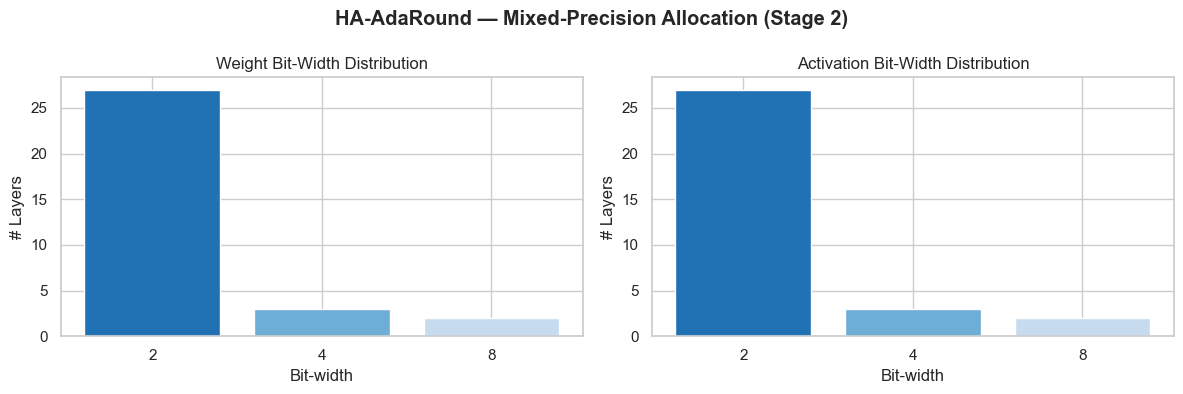

         layer  weight_bits  act_bits
         conv1            8         8
        layer1            2         2
      layer1.0            2         2
layer1.0.conv1            2         2
layer1.0.conv2            2         2
      layer1.1            2         2
layer1.1.conv1            2         2
layer1.1.conv2            2         2
      layer1.2            2         2
layer1.2.conv1            2         2
layer1.2.conv2            2         2
        layer2            2         2
      layer2.0            2         2
layer2.0.conv1            2         2
layer2.0.conv2            2         2
      layer2.1            2         2
layer2.1.conv1            2         2
layer2.1.conv2            2         2
      layer2.2            2         2
layer2.2.conv1            2         2
layer2.2.conv2            2         2
        layer3            4         4
      layer3.0            4         4
layer3.0.conv1            2         2
layer3.0.conv2            4         4
      layer3

In [32]:
quant_config = load_json("quant_config.json")

if quant_config:
    # quant_config schema (post-AdaRound):
    # { "layer_name": { "name": "integer", "weight_width": N,
    #                   "data_in_width": N, "bias_width": N, ... } }
    df_bits = pd.DataFrame(
        [
            {
                "layer": k,
                "weight_bits": v.get("weight_width", 8),
                "act_bits":    v.get("data_in_width", 8),
            }
            for k, v in quant_config.items()
            if isinstance(v, dict) and v.get("name") == "integer"
        ]
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col, title in zip(
        axes,
        ["weight_bits", "act_bits"],
        ["Weight Bit-Width Distribution", "Activation Bit-Width Distribution"],
    ):
        counts = df_bits[col].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values,
               color=sns.color_palette("Blues_r", len(counts)))
        ax.set_xlabel("Bit-width")
        ax.set_ylabel("# Layers")
        ax.set_title(title)

    plt.suptitle("HA-AdaRound — Mixed-Precision Allocation (Stage 2)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(df_bits[["layer", "weight_bits", "act_bits"]].to_string(index=False))

## 3. Model Compression Analysis

Estimate the memory footprint reduction achieved by mixed-precision allocation  
compared to a full fp32 (32-bit) baseline.  
Computed directly from `quant_config.json` — no additional output files needed.

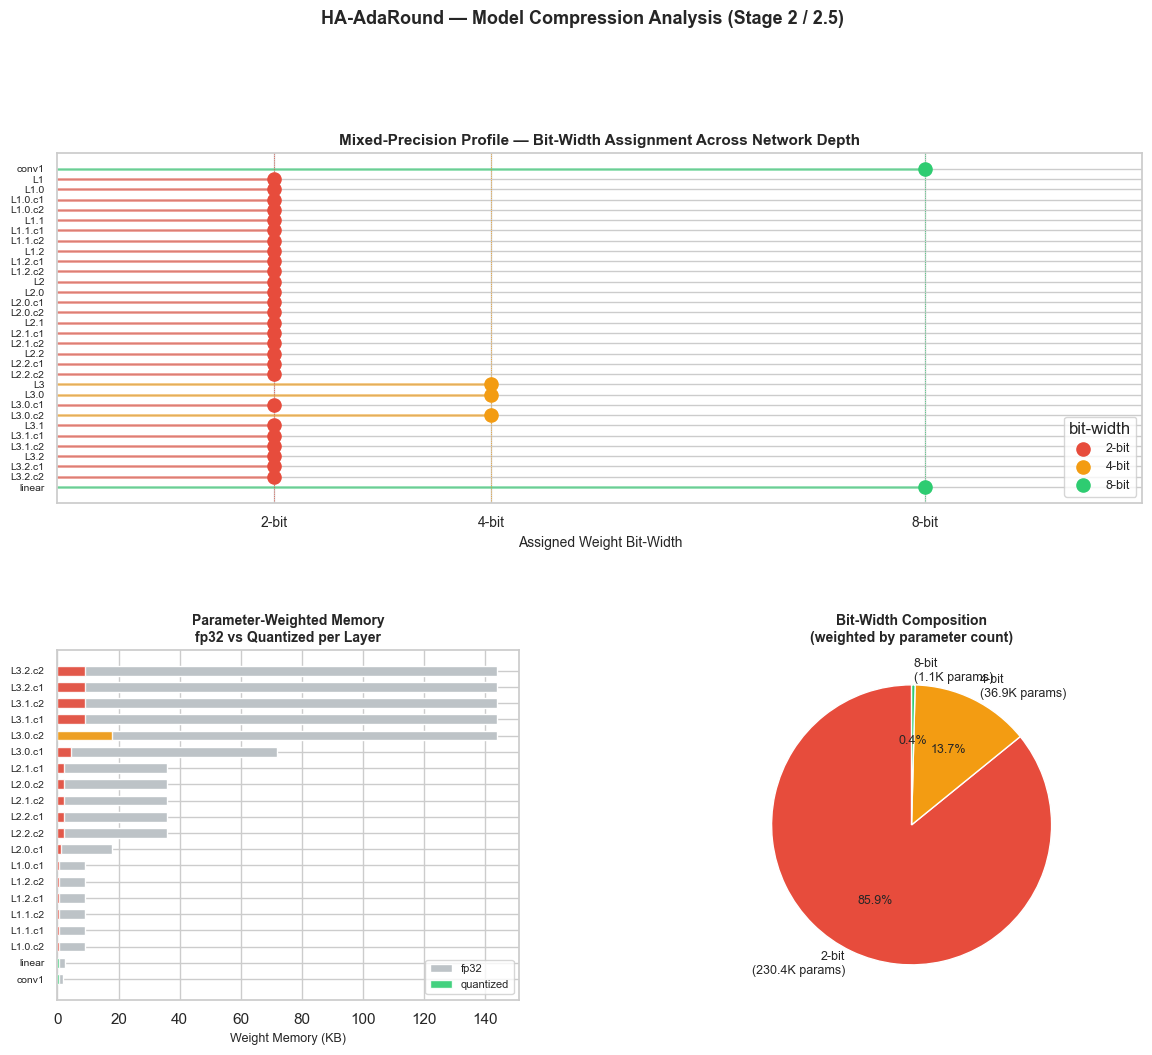

────────────────────────────────────────────────
  Quantized layers     : 32
  Total parameters     : 268,346
  fp32 weight memory   : 1.02 MB
  Quantized memory     : 0.07 MB
  Compression ratio    : 13.92x
  Memory saved         : 92.8%
  Param-weighted avg   : 2.30 bits  (fp32 = 32)
────────────────────────────────────────────────
         layer  weight_bits  n_params
         conv1            8       432
        layer1            2         0
      layer1.0            2         0
layer1.0.conv1            2      2304
layer1.0.conv2            2      2304
      layer1.1            2         0
layer1.1.conv1            2      2304
layer1.1.conv2            2      2304
      layer1.2            2         0
layer1.2.conv1            2      2304
layer1.2.conv2            2      2304
        layer2            2         0
      layer2.0            2         0
layer2.0.conv1            2      4608
layer2.0.conv2            2      9216
      layer2.1            2         0
layer2.1.conv1    

In [33]:
if quant_config:
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path("..").resolve()))
    from src.models import build_model
    import torch.nn as nn

    # ------------------------------------------------------------------ #
    # Build layer table: bit-width + real parameter counts
    # ------------------------------------------------------------------ #
    _model = build_model("resnet20", num_classes=10)
    _param_counts = {
        name: sum(p.numel() for p in module.parameters())
        for name, module in _model.named_modules()
        if isinstance(module, (nn.Conv2d, nn.Linear))
    }

    FP32_BITS = 32
    rows = []
    for layer, cfg in quant_config.items():
        if not isinstance(cfg, dict) or cfg.get("name") != "integer":
            continue
        w_bits  = cfg.get("weight_width", 8)
        n_params = _param_counts.get(layer, 0)
        rows.append({
            "layer":            layer,
            "weight_bits":      w_bits,
            "n_params":         n_params,
            "fp32_kb":          n_params * FP32_BITS / 8 / 1024,
            "quant_kb":         n_params * w_bits   / 8 / 1024,
            "compression":      FP32_BITS / w_bits if w_bits else 1,
        })

    df = pd.DataFrame(rows)
    df["depth_order"] = range(len(df))   # preserves network insertion order

    if df.empty:
        print("No quantized layers found in quant_config.json.")
    else:
        BIT_COLOR = {2: "#e74c3c", 4: "#f39c12", 8: "#2ecc71"}
        df["color"] = df["weight_bits"].map(BIT_COLOR).fillna("grey")

        fig = plt.figure(figsize=(14, 11))
        gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35)
        ax_profile = fig.add_subplot(gs[0, :])   # full-width top
        ax_mem     = fig.add_subplot(gs[1, 0])   # bottom-left
        ax_pie     = fig.add_subplot(gs[1, 1])   # bottom-right

        # -------------------------------------------------------------- #
        # Plot 1 — Network-depth bit-width profile (lollipop)
        # -------------------------------------------------------------- #
        y  = df["depth_order"]
        bw = df["weight_bits"]
        short_names = [l.replace("layer", "L").replace(".conv", ".c")
                         .replace(".linear", ".fc") for l in df["layer"]]

        ax_profile.hlines(y, 0, bw, colors=df["color"], linewidth=1.8, alpha=0.6)
        for bit_val, grp in df.groupby("weight_bits"):
            ax_profile.scatter(
                grp["weight_bits"], grp["depth_order"],
                color=BIT_COLOR.get(bit_val, "grey"),
                s=90, zorder=3, label=f"{bit_val}-bit",
            )
        ax_profile.set_yticks(y)
        ax_profile.set_yticklabels(short_names, fontsize=7.5)
        ax_profile.set_xticks([2, 4, 8])
        ax_profile.set_xticklabels(["2-bit", "4-bit", "8-bit"], fontsize=10)
        ax_profile.set_xlabel("Assigned Weight Bit-Width", fontsize=10)
        ax_profile.set_title(
            "Mixed-Precision Profile — Bit-Width Assignment Across Network Depth",
            fontsize=11, fontweight="bold",
        )
        ax_profile.invert_yaxis()   # layer 0 at top = network input
        ax_profile.axvline(8, color="#2ecc71", lw=0.6, linestyle=":")
        ax_profile.axvline(4, color="#f39c12", lw=0.6, linestyle=":")
        ax_profile.axvline(2, color="#e74c3c", lw=0.6, linestyle=":")
        ax_profile.legend(title="bit-width", fontsize=9, loc="lower right")
        ax_profile.set_xlim(0, 10)

        # -------------------------------------------------------------- #
        # Plot 2 — Parameter-weighted memory: fp32 vs quantized per layer
        # Sort by fp32 memory so biggest layers are most visible
        # -------------------------------------------------------------- #
        df_mem = df[df["n_params"] > 0].sort_values("fp32_kb", ascending=True)
        bar_y  = range(len(df_mem))
        short_m = [l.replace("layer", "L").replace(".conv", ".c")
                     .replace(".linear", ".fc") for l in df_mem["layer"]]

        ax_mem.barh(bar_y, df_mem["fp32_kb"],  color="#bdc3c7", label="fp32",      height=0.6)
        ax_mem.barh(bar_y, df_mem["quant_kb"], color=df_mem["color"], label="quantized", height=0.6, alpha=0.9)
        ax_mem.set_yticks(list(bar_y))
        ax_mem.set_yticklabels(short_m, fontsize=7.5)
        ax_mem.set_xlabel("Weight Memory (KB)", fontsize=9)
        ax_mem.set_title("Parameter-Weighted Memory\nfp32 vs Quantized per Layer", fontsize=10, fontweight="bold")
        ax_mem.legend(fontsize=8)

        # -------------------------------------------------------------- #
        # Plot 3 — Param-weighted bit-width composition pie
        # Weighted by parameter count so large layers dominate correctly
        # -------------------------------------------------------------- #
        weighted = df.groupby("weight_bits")["n_params"].sum()
        ax_pie.pie(
            weighted.values,
            labels=[f"{b}-bit\n({v/1000:.1f}K params)" for b, v in weighted.items()],
            colors=[BIT_COLOR.get(b, "grey") for b in weighted.index],
            autopct="%1.1f%%",
            startangle=90,
            textprops={"fontsize": 9},
        )
        ax_pie.set_title(
            "Bit-Width Composition\n(weighted by parameter count)",
            fontsize=10, fontweight="bold",
        )

        plt.suptitle("HA-AdaRound — Model Compression Analysis (Stage 2 / 2.5)",
                     fontsize=13, fontweight="bold", y=1.01)
        plt.savefig("compression_analysis.png", dpi=150, bbox_inches="tight")
        plt.show()

        # -------------------------------------------------------------- #
        # Printed summary
        # -------------------------------------------------------------- #
        total_params  = df["n_params"].sum()
        fp32_total_kb = df["fp32_kb"].sum()
        quant_total_kb= df["quant_kb"].sum()
        avg_bits      = (df["weight_bits"] * df["n_params"]).sum() / max(total_params, 1)
        ratio         = fp32_total_kb / max(quant_total_kb, 1e-9)

        print(f"{'─'*48}")
        print(f"  Quantized layers     : {len(df)}")
        print(f"  Total parameters     : {total_params:,}")
        print(f"  fp32 weight memory   : {fp32_total_kb/1024:.2f} MB")
        print(f"  Quantized memory     : {quant_total_kb/1024:.2f} MB")
        print(f"  Compression ratio    : {ratio:.2f}x")
        print(f"  Memory saved         : {(1 - 1/ratio)*100:.1f}%")
        print(f"  Param-weighted avg   : {avg_bits:.2f} bits  (fp32 = 32)")
        print(f"{'─'*48}")
        print(df[["layer","weight_bits","n_params"]].to_string(index=False))


## 4. Baseline vs. Quantized Accuracy Comparison

Compares fp32 baseline accuracy against the HA-AdaRound mixed-precision model.  
Requires `eval_baseline.json` and `eval_quantized.json` from the evaluator.

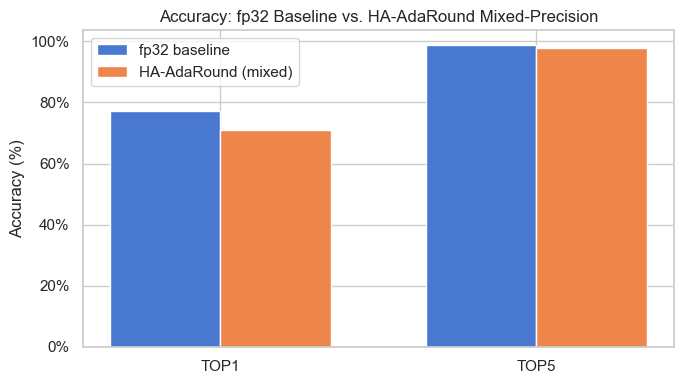

TOP1: baseline=77.18%  quantized=70.86%  drop=+6.32%
TOP5: baseline=98.69%  quantized=97.91%  drop=+0.78%


In [34]:
baseline  = load_json("eval_baseline.json").get("metrics", {})
quantized = load_json("eval_quantized.json").get("metrics", {})

if baseline and quantized:
    metrics = [k for k in baseline if k.startswith("top")]
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width/2, [baseline[m]  for m in metrics], width, label="fp32 baseline")
    ax.bar(x + width/2, [quantized[m] for m in metrics], width, label="HA-AdaRound (mixed)")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy: fp32 Baseline vs. HA-AdaRound Mixed-Precision")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()
    plt.tight_layout()
    plt.show()

    for m in metrics:
        drop = baseline[m] - quantized[m]
        print(f"{m.upper()}: baseline={baseline[m]:.2f}%  quantized={quantized[m]:.2f}%  drop={drop:+.2f}%")
else:
    print("Run the Evaluator to generate eval_baseline.json / eval_quantized.json first.")

## 5. Sensitivity Score vs. Assigned Bit-Width

Validates that the allocator policy is consistent with the profiler output.  
Each point is one layer — colour encodes its assigned bit-width.

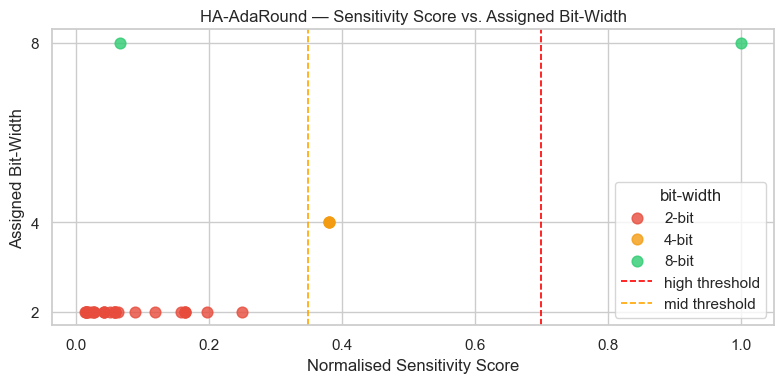

In [11]:
if layer_scores and quant_config:
    rows = []
    for layer, score in layer_scores.items():
        cfg = quant_config.get(layer, {})
        if isinstance(cfg, dict) and cfg.get("name") == "integer":
            rows.append({
                "layer": layer,
                "sensitivity": score,
                "weight_bits": cfg.get("weight_width", 8),
            })

    df_scatter = pd.DataFrame(rows)

    if not df_scatter.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        palette = {2: "#e74c3c", 4: "#f39c12", 8: "#2ecc71"}
        for bits, grp in df_scatter.groupby("weight_bits"):
            ax.scatter(grp["sensitivity"], [bits] * len(grp),
                       color=palette.get(bits, "grey"), label=f"{bits}-bit",
                       s=60, alpha=0.8)
        ax.axvline(0.70, color="red",    linestyle="--", lw=1.2, label="high threshold")
        ax.axvline(0.35, color="orange", linestyle="--", lw=1.2, label="mid threshold")
        ax.set_yticks([2, 4, 8])
        ax.set_xlabel("Normalised Sensitivity Score")
        ax.set_ylabel("Assigned Bit-Width")
        ax.set_title("HA-AdaRound — Sensitivity Score vs. Assigned Bit-Width")
        ax.legend(title="bit-width")
        plt.tight_layout()
        plt.show()